# 🍎 CONTROL DE CALIDAD DE FRUTAS — VISIÓN POR COMPUTADORA
### Prof. Oswaldo Velez Lanngs, PhD
### Metodología CRISP-DM · EfficientNetV2-S · Grad-CAM · Gradio

---

| Componente | Detalle |
|---|---|
| **Modelo** | EfficientNetV2-S (Transfer Learning desde ImageNet) |
| **Localización de daños** | Grad-CAM (Gradient-weighted Class Activation Mapping) |
| **Framework** | TensorFlow / Keras |
| **Despliegue** | Gradio (Web) → exportable a TFLite (Móvil) |
| **GPU objetivo** | T4 (15 GB) — Google Colab Education |
| **Estrategia de entrenamiento** | Checkpoints cada 5 épocas, guardado en Drive |

> **¿Por qué EfficientNetV2-S?** Investigaciones 2024-2025 demuestran que alcanza >99% de precisión en clasificación de calidad de frutas, supera a ResNet/VGG, entrena rápido en T4 y se exporta a TFLite sin degradación significativa.

---


## 📦 BLOQUE 1/13 — Instalación de Dependencias

In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 1/13 — INSTALACIÓN DE DEPENDENCIAS (FIXED)         ║
# ╚══════════════════════════════════════════════════════════════╝

print("🧹 Limpiando y configurando entorno estable...")
# Desinstalar versiones conflictivas
!pip uninstall -y gradio gradio_client huggingface_hub -q

# Instalar versiones con compatibilidad probada
!pip install -q huggingface_hub==0.24.5
!pip install -q "gradio==4.44.1"
!pip install -q kaggle

print("✅ Dependencias instaladas. IMPORTANTE: Reinicia la sesión (Entorno de ejecución > Reiniciar sesión) antes de continuar.")

🧹 Limpiando y configurando entorno estable...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.5/417.5 kB 4.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.19.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.24.5 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.24.5 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.24.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 11.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not cur

## ⚙️ BLOQUE 2/13 — Importaciones y Configuración Global

In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 2/13 — IMPORTACIONES Y CONFIGURACIÓN GLOBAL         ║
# ╚══════════════════════════════════════════════════════════════╝

import os, sys, json, hashlib, shutil, time, random, warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm_plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from PIL import Image, ImageFile
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.applications import EfficientNetV2S
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
ImageFile.LOAD_TRUNCATED_IMAGES = True  # tolerar imágenes ligeramente corruptas

# ── GPU: memoria dinámica para evitar OOM ────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# ── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 55)
print(f"  TensorFlow  : {tf.__version__}")
print(f"  GPU activa  : {[g.name for g in gpus] or 'CPU (sin GPU)'}")
try:
    ram_info = os.popen("free -h | grep Mem").read().split()
    print(f"  RAM total   : {ram_info[1]}  |  Libre: {ram_info[3]}")
except:
    pass
try:
    disk_info = os.popen("df -h /content | tail -1").read().split()
    print(f"  Disco total : {disk_info[1]}  |  Libre: {disk_info[3]}")
except:
    pass
print("=" * 55)
print("✅ Configuración global lista")


  TensorFlow  : 2.20.0
  GPU activa  : CPU (sin GPU)
  RAM total   : 12Gi  |  Libre: 7.1Gi
  Disco total : 108G  |  Libre: 88G
✅ Configuración global lista


## 📁 BLOQUE 3/13 — Montaje de Drive y Rutas del Proyecto

In [18]:
import os
from google.colab import drive

drive.mount('/content/drive')

# ════════════════════════════════════════
#  ⚙‸  EXTRACCIÓN DE DATASET Y RUTAS (CORREGIDO PARA FRESH/ROTTEN)
# ════════════════════════════════════════

DATASET_ZIP = '/content/drive/MyDrive/Dataset Detector Frutas/food-freshness-dataset.zip'
LOCAL_EXTRACT = '/content/dataset_local'

if not os.path.exists(LOCAL_EXTRACT):
    print("⌒ Descomprimiendo dataset...")
    !unzip -q "{DATASET_ZIP}" -d {LOCAL_EXTRACT}

# Lógica corregida: Buscamos la carpeta que contiene 'Fresh' y 'Rotten'
DATASET_ROOT = LOCAL_EXTRACT
found = False
for root, dirs, files in os.walk(LOCAL_EXTRACT):
    # Si encontramos una carpeta que contiene 'Fresh' y 'Rotten' simultáneamente
    if 'Fresh' in dirs and 'Rotten' in dirs:
        DATASET_ROOT = root
        found = True
        break

if not found:
    # Fallback: buscar la carpeta 'Dataset' si existe
    for root, dirs, files in os.walk(LOCAL_EXTRACT):
        if 'Dataset' in dirs:
            DATASET_ROOT = os.path.join(root, 'Dataset')
            break

PROJECT_ROOT = '/content/drive/MyDrive/FrutasProyecto'
os.makedirs(PROJECT_ROOT, exist_ok=True) # Explicitly create PROJECT_ROOT

# ── Hiperparámetros globales ──
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_PER_RUN = 5
TARGET_EPOCHS = 50
HEAD_EPOCHS = 15
MAX_PER_CLASS = 2000
MIN_PER_CLASS = 100
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

DIRS = {
    'checkpoints' : f'{PROJECT_ROOT}/checkpoints',
    'logs'        : f'{PROJECT_ROOT}/logs',
    'results'     : f'{PROJECT_ROOT}/results',
    'models'      : f'{PROJECT_ROOT}/models',
    'gradcam'     : f'{PROJECT_ROOT}/gradcam',
}

for d in DIRS.values():
    os.makedirs(d, exist_ok=True)

STATE_FILE   = f'{PROJECT_ROOT}/training_state.json'
SPLIT_FILE   = f'{PROJECT_ROOT}/split_info.json'
BEST_CKPT    = f'{DIRS["checkpoints"]}/best_model.weights.h5'
LATEST_CKPT  = f'{DIRS["checkpoints"]}/latest_model.weights.h5'

print(f"\nDataset Raíz: {DATASET_ROOT}")
if os.path.exists(DATASET_ROOT):
    subdirs = [d for d in os.listdir(DATASET_ROOT) if os.path.isdir(os.path.join(DATASET_ROOT, d))]
    print(f"   Carpetas principales encontradas: {subdirs}")
    n_files = sum(len(files) for _, _, files in os.walk(DATASET_ROOT))
    print(f"   Estado  : ✅ ENCONTRADO (~{n_files} archivos)")

Mounted at /content/drive
⌒ Descomprimiendo dataset...

Dataset Raíz: /content/dataset_local/Dataset
   Carpetas principales encontradas: ['Rotten', 'Fresh']
   Estado  : ✅ ENCONTRADO (~71322 archivos)


## 🔍 BLOQUE 4/13 — EDA: Análisis de Estructura y Clases

> **CRISP-DM Etapa 2: Data Understanding**  
> Responde: ¿Cuántas clases hay? ¿Cuántas imágenes? ¿Están balanceadas? ¿Hay dominantes?


In [ ]:
# ╔═══════════════════════════════════════════════════════════╔
# ║  BLOQUE 4/13 — EDA: ESCANEANDO FRESH Y ROTTEN             ║
# ═══════════════════════════════════════════════════════════

def scan_dataset_v2(root):
    """
    Escanea el dataset unificando el estado (Fresh/Rotten) con el nombre del fruto.
    """
    root = Path(root)
    class_files = defaultdict(list)
    VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}
    for img_path in root.rglob('*'):
        if img_path.suffix.lower() in VALID_EXT:
            parts = img_path.parts
            if len(parts) >= 2:
                # La clase es 'Estado_Fruto' (ej: Fresh_Apple)
                class_name = f"{img_path.parent.parent.name}_{img_path.parent.name}"
                class_files[class_name].append(str(img_path))
    return dict(class_files)

print("ခ Escaneando dataset completo (Fresh + Rotten)...")
class_files = scan_dataset_v2(DATASET_ROOT)

class_counts = {cls: len(files) for cls, files in class_files.items()}
total_imgs   = sum(class_counts.values())
CLASS_NAMES  = sorted(class_files.keys())
N_CLASSES    = len(CLASS_NAMES)

# ── Tabla de clases visual ────────────────────────
print("═" * 75)
print(f"  {'CLASE':<30} {'IMGENES':>10}  {'%':>7}  BARRA")
print("═" * 75)
max_count = max(class_counts.values())
for cls in CLASS_NAMES:
    cnt  = class_counts[cls]
    pct  = 100 * cnt / total_imgs
    bar  = '█' * int(cnt / max_count * 20)
    print(f"  {cls:<30} {cnt:>10}  {pct:>6.1f}%  {bar}")
print("═" * 75)
print(f"  {'TOTAL':<30} {total_imgs:>10}")

# ── Anplisis de balance ────────────────────────────
counts  = list(class_counts.values())
mn, mx  = min(counts), max(counts)
ratio   = mx / mn if mn > 0 else float('inf')
media   = np.mean(counts)

print(f"\nဃ ANLISIS DE BALANCE:")
print(f"   N de clases       : {N_CLASSES}")
print(f"   Total impgenes     : {total_imgs}")
print(f"   Clase mps grande   : {mx} impgenes ({CLASS_NAMES[counts.index(mx)]})")
print(f"   Clase mps pequea  : {mn} impgenes ({CLASS_NAMES[counts.index(mn)]})")
print(f"   Ratio max/min      : {ratio:.2f}x")
print(f"   Media por clase    : {media:.0f}")

if ratio < 1.5:
    print("   Veredicto          : ✅ BIEN BALANCEADO")
elif ratio < 4.0:
    print("   Veredicto          : ☁‸  LIGERAMENTE DESBALANCEADO")
else:
    print("   Veredicto          : ❌ MUY DESBALANCEADO → balanceo agresivo necesario")

print(f"\nခ Clases detectadas: {CLASS_NAMES}")

ခ Escaneando dataset completo (Fresh + Rotten)...
═══════════════════════════════════════════════════════════════════════════
  CLASE                            IMGENES        %  BARRA
═══════════════════════════════════════════════════════════════════════════
  Fresh_FreshApple                     3431     4.8%  █████
  Fresh_FreshBanana                    3473     4.9%  █████
  Fresh_FreshBellpepper                 611     0.9%  
  Fresh_FreshBittergroud                327     0.5%  
  Fresh_FreshCapciscum                  990     1.4%  █
  Fresh_FreshCarrot                    9899    13.9%  ██████████████
  Fresh_FreshCucumber                  1104     1.5%  █
  Fresh_FreshMango                      605     0.8%  
  Fresh_FreshOkara                      635     0.9%  
  Fresh_FreshOrange                   10831    15.2%  ███████████████
  Fresh_FreshPotato                    1151     1.6%  █
  Fresh_FreshStrawberry                 603     0.8%  
  Fresh_FreshTomato                 

## 📊 BLOQUE 5/13 — EDA: Visualizaciones, Muestras y Resoluciones

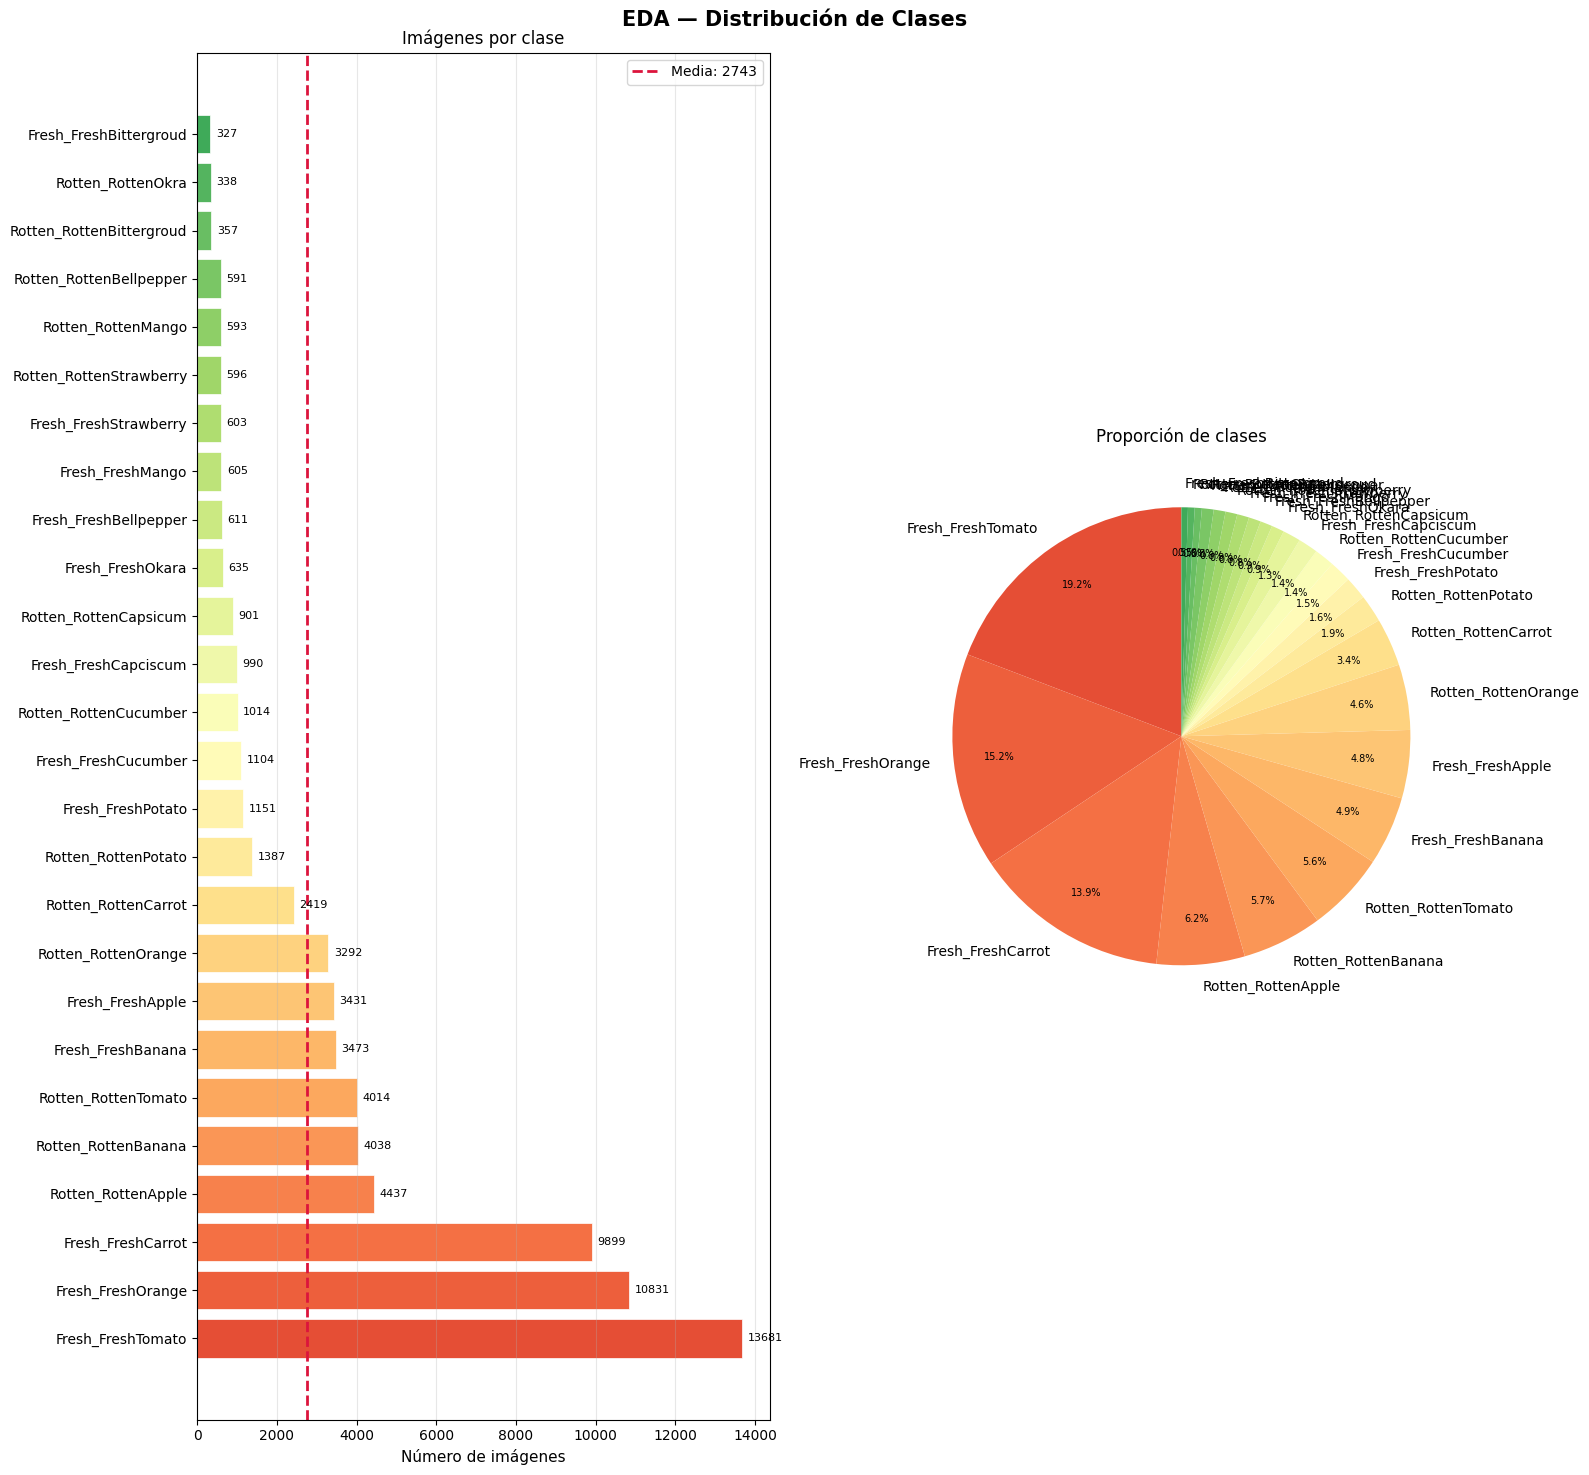

💾 01_class_distribution.png guardado en Drive


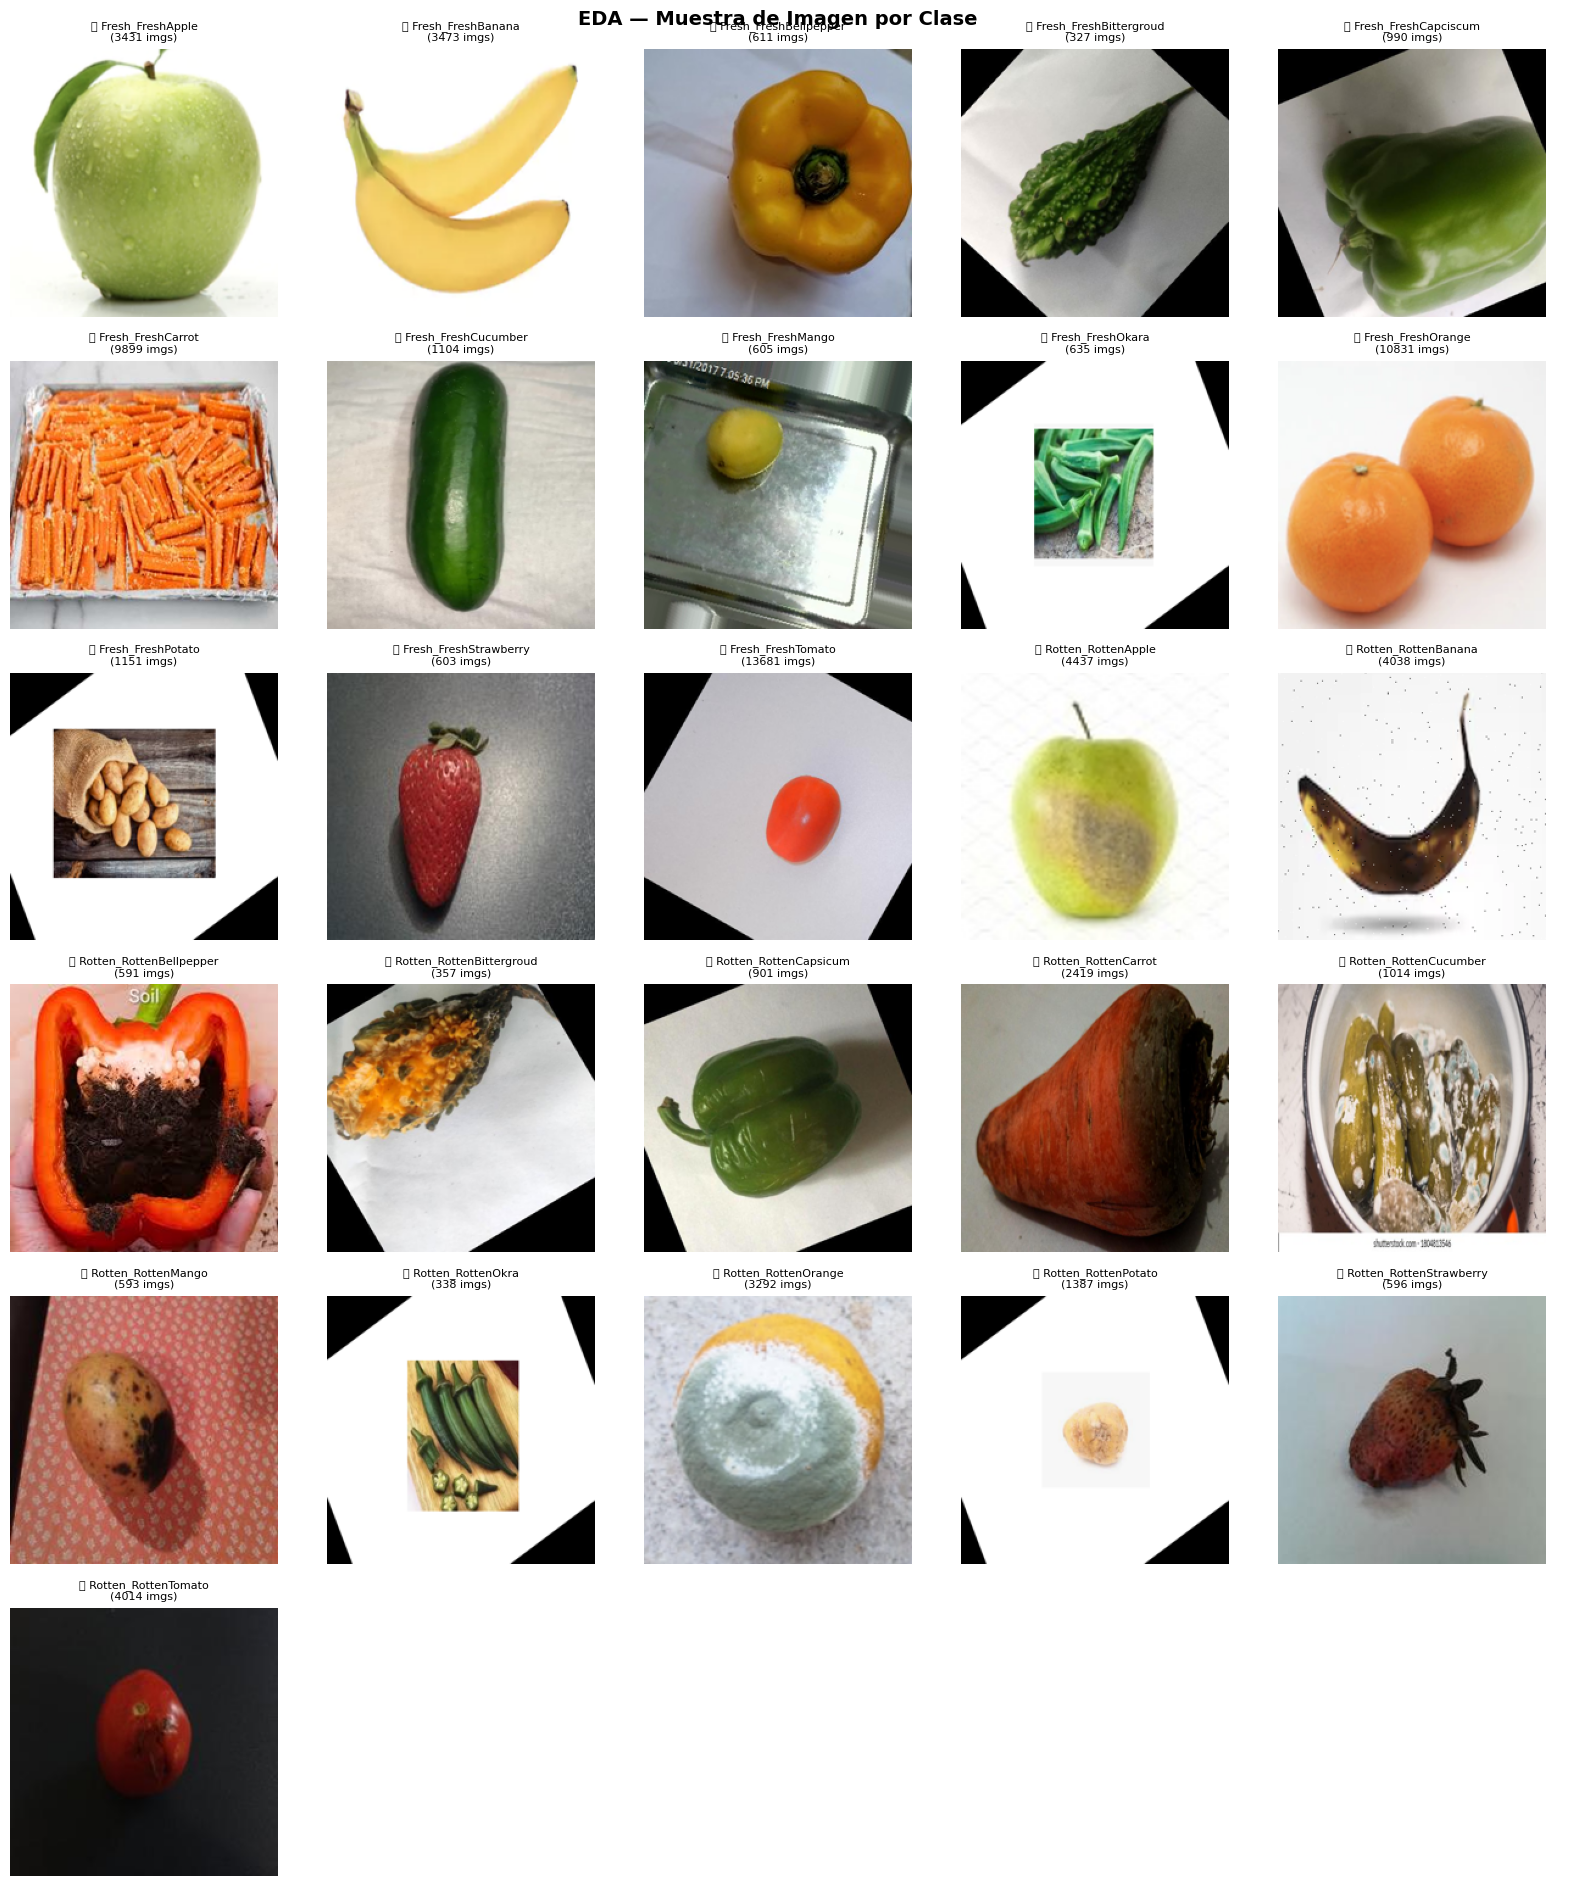

💾 02_class_samples.png guardado en Drive

📐 Analizando resoluciones (muestra 50 imgs/clase)...

  Estadísticas de resolución por clase:
                           ancho              alto           
                            mean  min   max   mean  min   max
clase                                                        
Fresh_FreshApple           330.0  100   775  310.0  100   497
Fresh_FreshBanana          434.0  202   862  328.0  140   478
Fresh_FreshBellpepper      365.0  100  4288  344.0  100  2891
Fresh_FreshBittergroud     512.0  512   512  512.0  512   512
Fresh_FreshCapciscum       512.0  512   512  512.0  512   512
Fresh_FreshCarrot          742.0  100  4624  591.0  100  2848
Fresh_FreshCucumber        657.0  100  4254  506.0  100  3273
Fresh_FreshMango           257.0  224   320  236.0  224   258
Fresh_FreshOkara           450.0  450   450  320.0  320   320
Fresh_FreshOrange          529.0  100  2000  512.0  100  2048
Fresh_FreshPotato          388.0  100  1920  312.0  100  1

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 5/13 — EDA: VISUALIZACIONES Y MUESTRAS              ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 1. Distribución de clases ─────────────────────────────────────────────────
sorted_pairs   = sorted(class_counts.items(), key=lambda x: -x[1])
cls_sorted, cnt_sorted = zip(*sorted_pairs)
palette = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(cls_sorted)))

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, N_CLASSES * 0.5 + 2)))
fig.suptitle('EDA — Distribución de Clases', fontsize=15, fontweight='bold')

# Barras horizontales
bars = axes[0].barh(cls_sorted, cnt_sorted, color=palette, edgecolor='white', linewidth=0.5)
axes[0].axvline(x=np.mean(cnt_sorted), color='crimson', linestyle='--', lw=2,
                label=f'Media: {np.mean(cnt_sorted):.0f}')
for bar, cnt in zip(bars, cnt_sorted):
    axes[0].text(cnt + max(cnt_sorted)*0.01, bar.get_y() + bar.get_height()/2,
                 str(cnt), va='center', fontsize=8)
axes[0].set_xlabel('Número de imágenes', fontsize=11)
axes[0].set_title('Imágenes por clase', fontsize=12)
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Pastel
wedges, texts, autotexts = axes[1].pie(
    cnt_sorted, labels=cls_sorted, autopct='%1.1f%%',
    colors=palette, startangle=90, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(7)
axes[1].set_title('Proporción de clases', fontsize=12)

plt.tight_layout()
plt.savefig(f"{DIRS['results']}/01_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("💾 01_class_distribution.png guardado en Drive")

# ── 2. Muestras por clase ─────────────────────────────────────────────────────
n_cols = min(5, N_CLASSES)
n_rows = (N_CLASSES + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 3.2))
fig.suptitle('EDA — Muestra de Imagen por Clase', fontsize=14, fontweight='bold')
axes_flat = np.array(axes).flatten() if N_CLASSES > 1 else [axes]

for i, cls in enumerate(CLASS_NAMES):
    sample_path = random.choice(class_files[cls])
    try:
        img = Image.open(sample_path).convert('RGB').resize((220, 220))
        axes_flat[i].imshow(img)
        status = "🟢" if 'fresh' in cls.lower() or 'sano' in cls.lower() else "🔴"
        axes_flat[i].set_title(f'{status} {cls}\n({class_counts[cls]} imgs)', fontsize=8)
    except Exception as e:
        axes_flat[i].set_title(f'{cls}\nERROR', fontsize=7, color='red')
    axes_flat[i].axis('off')

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

plt.tight_layout()
plt.savefig(f"{DIRS['results']}/02_class_samples.png", dpi=150, bbox_inches='tight')
plt.show()
print("💾 02_class_samples.png guardado en Drive")

# ── 3. Análisis de resoluciones ───────────────────────────────────────────────
print("\n📐 Analizando resoluciones (muestra 50 imgs/clase)...")
res_data = []
for cls in CLASS_NAMES:
    sample = random.sample(class_files[cls], min(50, len(class_files[cls])))
    for p in sample:
        try:
            with Image.open(p) as img:
                res_data.append({'clase': cls, 'ancho': img.width, 'alto': img.height,
                                  'modo': img.mode})
        except:
            pass

df_res = pd.DataFrame(res_data)
print("\n  Estadísticas de resolución por clase:")
print(df_res.groupby('clase')[['ancho', 'alto']].agg(['mean', 'min', 'max']).round(0).to_string())
print(f"\n  Modos de color: {df_res['modo'].value_counts().to_dict()}")
print("\n✅ EDA de estructura y muestras completado")


## 🧹 BLOQUE 6/13 — EDA: Duplicados, Corruptas y Calidad del Dataset

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 6/13 — DETECCIÓN DE DUPLICADOS E IMÁGENES CORRUPTAS ║
# ╚══════════════════════════════════════════════════════════════╝

def file_md5(path, chunk=8192):
    """Hash MD5 del contenido binario del archivo."""
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while data := f.read(chunk):
            h.update(data)
    return h.hexdigest()

def is_valid_image(path):
    """Verifica que la imagen sea legible y no esté corrupta."""
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert('RGB')
        return True
    except:
        return False

print("🔍 Verificando integridad y buscando duplicados...")
print("   (puede tardar varios minutos según el tamaño del dataset)\n")

hash_map    = defaultdict(list)
corrupts    = []
total_files = sum(len(v) for v in class_files.values())
checked     = 0

for cls, paths in class_files.items():
    for p in paths:
        checked += 1
        if checked % 200 == 0:
            print(f"   Progreso: {checked}/{total_files} ({100*checked/total_files:.1f}%)", end='\r')

        if not is_valid_image(p):
            corrupts.append(p)
        else:
            h = file_md5(p)
            hash_map[h].append(p)

duplicates     = {h: ps for h, ps in hash_map.items() if len(ps) > 1}
n_dup_extra    = sum(len(ps) - 1 for ps in duplicates.values())
valid_total    = total_files - len(corrupts)

print(f"\n\n{'═'*55}")
print(f"  REPORTE DE CALIDAD DEL DATASET")
print(f"{'═'*55}")
print(f"  Total archivos escaneados  : {total_files:>8}")
print(f"  Imágenes válidas           : {valid_total:>8}")
print(f"  Imágenes corruptas         : {len(corrupts):>8}  {'✅' if not corrupts else '❌ se eliminarán'}")
print(f"  Grupos de duplicados       : {len(duplicates):>8}  {'✅' if not duplicates else '⚠️  se eliminarán extras'}")
print(f"  Archivos duplicados extra  : {n_dup_extra:>8}  {'✅' if not n_dup_extra else '⚠️  se eliminarán'}")
print(f"{'═'*55}")

if corrupts:
    print(f"\n❌ Primeras imágenes corruptas:")
    for p in corrupts[:5]:
        print(f"   {p}")

if duplicates:
    print(f"\n⚠️  Ejemplos de duplicados encontrados:")
    for h, paths in list(duplicates.items())[:3]:
        print(f"   Hash {h[:10]}...: {len(paths)} copias")
        for pp in paths[:2]:
            print(f"     → {pp}")

print("\n✅ Análisis de calidad completado")


🔍 Verificando integridad y buscando duplicados...
   (puede tardar varios minutos según el tamaño del dataset)



═══════════════════════════════════════════════════════
  REPORTE DE CALIDAD DEL DATASET
═══════════════════════════════════════════════════════
  Total archivos escaneados  :    71318
  Imágenes válidas           :    71318
  Imágenes corruptas         :        0  ✅
  Grupos de duplicados       :    10665  ⚠️  se eliminarán extras
  Archivos duplicados extra  :    12071  ⚠️  se eliminarán
═══════════════════════════════════════════════════════

⚠️  Ejemplos de duplicados encontrados:
   Hash 8c0fa3e8d1...: 3 copias
     → /content/dataset_local/Dataset/Fresh/FreshBanana/translation_Screen Shot 2018-06-12 at 9.50.38 PM.png
     → /content/dataset_local/Dataset/Fresh/FreshBanana/b_f409.png
   Hash 693209fd56...: 2 copias
     → /content/dataset_local/Dataset/Fresh/FreshBanana/b_f566.png
     → /content/dataset_local/Dataset/Fresh/FreshBanana/Screen Shot 2018-06-12 at 10.06.1

## ⚖️ BLOQUE 7/13 — Limpieza, Balanceo y Split Train/Val/Test

> **CRISP-DM Etapa 3: Data Preparation**  
> Elimina corruptas y duplicados, balancea clases, divide el dataset.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 7/13 — LIMPIEZA, BALANCEO Y SPLIT                   ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 1. Construcción del dataset limpio ───────────────────────────────────────
corrupt_set    = set(corrupts)
dups_to_remove = set()
for h, paths in duplicates.items():
    for p in paths[1:]:          # conservar solo el primero de cada grupo
        dups_to_remove.add(p)

clean_class_files = defaultdict(list)
for cls, paths in class_files.items():
    for p in paths:
        if p not in corrupt_set and p not in dups_to_remove:
            clean_class_files[cls].append(p)

print("🧹 Dataset limpio (sin corruptas ni duplicados extra):")
for cls in CLASS_NAMES:
    orig  = len(class_files[cls])
    clean = len(clean_class_files[cls])
    print(f"   {cls:<35} {clean:>6}  (eliminadas: {orig-clean})")

# ── 2. Balanceo de clases ─────────────────────────────────────────────────────
# Estrategia: undersampling al máximo razonable.
# Las clases pequeñas se reforzarán con Data Augmentation online en entrenamiento.
print("\n⚖️  Calculando objetivo de balanceo...")

clean_counts   = {cls: len(files) for cls, files in clean_class_files.items()}
min_clean      = min(clean_counts.values())
# Objetivo: no exceder MAX_PER_CLASS ni el triple del mínimo (evita ratio >3)
target_count   = min(MAX_PER_CLASS, min_clean * 3, max(clean_counts.values()))
target_count   = max(target_count, MIN_PER_CLASS)
print(f"   Target por clase: {target_count}")

balanced = {}
for cls in CLASS_NAMES:
    files = clean_class_files[cls].copy()
    if len(files) > target_count:
        random.seed(SEED)
        files = random.sample(files, target_count)
    balanced[cls] = files

print("\n📊 Dataset balanceado final:")
for cls in CLASS_NAMES:
    cnt = len(balanced[cls])
    bar = '█' * int(cnt / target_count * 20)
    print(f"   {cls:<35} {cnt:>6}  {bar}")
total_balanced = sum(len(v) for v in balanced.values())
print(f"   {'TOTAL':<35} {total_balanced:>6}")

# Ratio final
bals = [len(v) for v in balanced.values()]
ratio_final = max(bals) / min(bals)
print(f"\n   Ratio max/min FINAL: {ratio_final:.2f}x  {'✅ Balanceado' if ratio_final < 2 else '⚠️  Tolerable'}")

# ── 3. Split estratificado train / val / test ──────────────────────────────────
print("\n✂️  Dividiendo en Train / Val / Test (estratificado por clase)...")

split_paths  = {'train': [], 'val': [], 'test': []}
split_labels = {'train': [], 'val': [], 'test': []}

for cls_idx, cls in enumerate(CLASS_NAMES):
    files = balanced[cls]
    # Separar test
    train_val, test = train_test_split(files, test_size=TEST_SPLIT,
                                        random_state=SEED, shuffle=True)
    # Separar val del resto
    val_frac = VAL_SPLIT / (1.0 - TEST_SPLIT)
    train, val = train_test_split(train_val, test_size=val_frac,
                                   random_state=SEED, shuffle=True)
    for split, subset in [('train', train), ('val', val), ('test', test)]:
        split_paths[split].extend(subset)
        split_labels[split].extend([cls_idx] * len(subset))

print(f"\n   {'Split':<8} {'Imágenes':>9} {'%':>7}")
print("   " + "─"*26)
for split in ['train', 'val', 'test']:
    n   = len(split_paths[split])
    pct = 100 * n / total_balanced
    print(f"   {split.upper():<8} {n:>9}  ({pct:.1f}%)")

# Guardar splits en Drive para reproducibilidad
split_info = {
    'class_names'  : CLASS_NAMES,
    'n_classes'    : N_CLASSES,
    'target_count' : target_count,
    'seed'         : SEED,
    'img_size'     : IMG_SIZE,
    'splits': {
        s: [{'path': p, 'label': l}
            for p, l in zip(split_paths[s], split_labels[s])]
        for s in ['train', 'val', 'test']
    }
}
with open(SPLIT_FILE, 'w') as f:
    json.dump(split_info, f, indent=2)
print(f"\n💾 Split guardado: {SPLIT_FILE}")
print("✅ Preparación de datos completada")


🧹 Dataset limpio (sin corruptas ni duplicados extra):
   Fresh_FreshApple                      2636  (eliminadas: 795)
   Fresh_FreshBanana                     2585  (eliminadas: 888)
   Fresh_FreshBellpepper                  600  (eliminadas: 11)
   Fresh_FreshBittergroud                 327  (eliminadas: 0)
   Fresh_FreshCapciscum                   990  (eliminadas: 0)
   Fresh_FreshCarrot                     9384  (eliminadas: 515)
   Fresh_FreshCucumber                    928  (eliminadas: 176)
   Fresh_FreshMango                       605  (eliminadas: 0)
   Fresh_FreshOkara                       609  (eliminadas: 26)
   Fresh_FreshOrange                     8678  (eliminadas: 2153)
   Fresh_FreshPotato                     1146  (eliminadas: 5)
   Fresh_FreshStrawberry                  603  (eliminadas: 0)
   Fresh_FreshTomato                    11114  (eliminadas: 2567)
   Rotten_RottenApple                    3250  (eliminadas: 1187)
   Rotten_RottenBanana                   3107

## 🔄 BLOQUE 8/13 — Pipeline tf.data con Data Augmentation

♨  Cargando splits guardados desde Drive...
✅ Splits cargados desde Drive
🔧 Creando pipelines tf.data (Versión Anti-Crashes)...

✅ Pipelines creados con éxito:
   Train :  14486 imgs → 453 batches
   Val   :   3110 imgs → 98 batches
   Test  :   3127 imgs → 98 batches


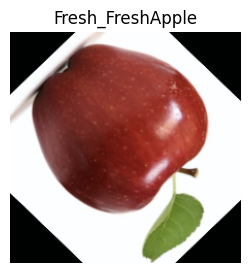

In [19]:
import math
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# ╔══════════════════════════════════════════════════════════════════╗
# ║  BLOQUE 8/13 — PIPELINE tf.data (SIN FUGAS DE MEMORIA)       ║
# ║═══════════════════════════════════════════════════════════════════════════════════════════════════║

# --- Definiciones de rutas necesarias ---
PROJECT_ROOT = "/content/drive/MyDrive/FrutasProyecto"
SPLIT_FILE   = f"{PROJECT_ROOT}/split_info.json"
IMG_SIZE     = 224
BATCH_SIZE   = 32
SEED         = 42

if "split_paths" not in dir() or not split_paths["train"]:
    print("♨  Cargando splits guardados desde Drive...")
    if not os.path.exists(SPLIT_FILE):
        raise FileNotFoundError(f"❌ No se encontró el archivo de splits en: {SPLIT_FILE}. Ejecuta el Bloque 7 primero.")

    with open(SPLIT_FILE) as f:
        si = json.load(f)
    CLASS_NAMES  = si["class_names"]
    N_CLASSES    = si["n_classes"]
    split_paths  = {s: [d["path"]  for d in si["splits"][s]] for s in ["train","val","test"]}
    split_labels = {s: [d["label"] for d in si["splits"][s]] for s in ["train","val","test"]}
    print("✅ Splits cargados desde Drive")

PARALLEL_CALLS = 2

# 🔥 SOLUCIÓN CRÍTICA: Usar tf.image nativo (100% seguro contra Memory Leaks)
@tf.function
def augment_image_native(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.25)
    img = tf.image.random_contrast(img, lower=0.75, upper=1.25)
    return img, label

@tf.function
def load_image_and_label(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    label_oh = tf.one_hot(label, N_CLASSES)
    return img, label_oh

@tf.function
def final_preprocessing(img, label):
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet_v2.preprocess_input(img)
    return img, label

def make_tf_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=512, seed=SEED)

    # 1. Carga y redimensiona (Ligero)
    ds = ds.map(load_image_and_label, num_parallel_calls=PARALLEL_CALLS)

    # 2. Data Augmentation NATIVO (Sin Leaks de RAM)
    if augment:
        ds = ds.map(augment_image_native, num_parallel_calls=PARALLEL_CALLS)

    # 3. Agrupar en Lotes
    ds = ds.batch(BATCH_SIZE)

    # 4. Formato final para EfficientNet
    ds = ds.map(final_preprocessing, num_parallel_calls=PARALLEL_CALLS)

    ds = ds.prefetch(1)
    return ds

print("🔧 Creando pipelines tf.data (Versión Anti-Crashes)...")
train_ds = make_tf_dataset(split_paths["train"], split_labels["train"], augment=True, shuffle=True)
val_ds   = make_tf_dataset(split_paths["val"],   split_labels["val"])
test_ds  = make_tf_dataset(split_paths["test"],  split_labels["test"])

n_train_batches = math.ceil(len(split_paths["train"]) / BATCH_SIZE)
n_val_batches   = math.ceil(len(split_paths["val"]) / BATCH_SIZE)
n_test_batches  = math.ceil(len(split_paths["test"]) / BATCH_SIZE)

print(f"\n✅ Pipelines creados con éxito:")
print(f"   Train : {len(split_paths['train']):>6} imgs → {n_train_batches} batches")
print(f"   Val   : {len(split_paths['val']):>6} imgs → {n_val_batches} batches")
print(f"   Test  : {len(split_paths['test']):>6} imgs → {n_test_batches} batches")

# Visualizar muestra rápida
for sample_imgs, sample_labels in train_ds.take(1):
    plt.figure(figsize=(3, 3))
    img = sample_imgs[0].numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    plt.imshow(img)
    plt.title(CLASS_NAMES[int(np.argmax(sample_labels[0].numpy()))])
    plt.axis("off")
    plt.show()

## 🏗️ BLOQUE 9/13 — Arquitectura del Modelo: EfficientNetV2-S

> **¿Por qué EfficientNetV2-S?**  
> - Mejor accuracy/eficiencia entre CNNs modernas para clasificación de frutas (2024-2025)  
> - Investigaciones recientes: >99% precisión en detección de enfermedades/calidad de frutas  
> - Entrenamiento progresivo incorporado — eficiente en T4  
> - ~20M parámetros — cabe en 15GB RAM con BATCH_SIZE=32  
> - Exportable a TFLite para móvil sin degradación significativa  


In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 9/13 — CONSTRUCCIÓN CON LABEL SMOOTHING             ║
# ╚══════════════════════════════════════════════════════════════╝

print("🏗️ Construyendo arquitectura con Label Smoothing...")

# 1. Cargar base preentrenada
base_model = keras.applications.EfficientNetV2S(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# 2. Congelar base para fase inicial
base_model.trainable = False

# 3. Cabeza del modelo
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name='avg_pool')(x)
x = layers.Dropout(0.4, name='top_dropout')(x)
outputs = layers.Dense(N_CLASSES, activation='softmax', name='predicciones')(x)

model = keras.Model(inputs, outputs)

# 4. Compilación con LABEL SMOOTHING
# Esto evita el sobreajuste y mejora la calibración de las probabilidades
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # 👈 ¡Aquí está el secreto!
    metrics=['accuracy']
)

print(f"✅ Modelo listo. Se aplicó un factor de suavizado de 0.1 en la función de pérdida.")

🏗️ Construyendo arquitectura con Label Smoothing...
✅ Modelo listo. Se aplicó un factor de suavizado de 0.1 en la función de pérdida.


## 🚀 BLOQUE 10/13 — Sesión de Entrenamiento (5 Épocas)

> **▶ Ejecuta este bloque repetidamente** para avanzar de 5 en 5 épocas.  
> El sistema detecta automáticamente en qué época quedaste y en qué fase (HEAD o FINE-TUNE).  
> Todo se guarda en Drive al terminar cada sesión.


In [ ]:
import os
import tensorflow as tf
from tensorflow import keras

# 🛡️ Protección contra fugas de memoria en la GPU antes de empezar
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_cpu_global_jit=false'

# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 10/13 — SESIÓN DE ENTRENAMIENTO SECUENCIAL (FIXED)   ║
# ╚══════════════════════════════════════════════════════════════╝

print("🚀 INICIANDO SESIÓN DE ENTRENAMIENTO...")

# ── 🛡️ SEGURIDAD: Recuperar variables perdidas por reinicio de Kernel ──
if 'CHECKPOINT_PATH' not in locals() and 'CHECKPOINT_PATH' not in globals():
    print("ℹ️ 'CHECKPOINT_PATH' no se encontró en memoria (Kernel reiniciado).")
    # Intentamos usar la ruta estándar del proyecto en Drive
    BACKUP_DIR = "/content/drive/MyDrive/FrutasProyecto/checkpoints"
    os.makedirs(BACKUP_DIR, exist_ok=True)
    CHECKPOINT_PATH = os.path.join(BACKUP_DIR, "best_model.weights.h5")
    print(f"✅ Ruta de checkpoints reconfigurada en: {CHECKPOINT_PATH}")

if 'class_weights' not in locals() and 'class_weights' not in globals():
    print("ℹ️ 'class_weights' no encontrado. Se asignará None (entrenamiento estándar).")
    class_weights = None

# ── Configuración de la fase ──
EPOCHS_PER_RUN = 20
phase = 'finetune'      # MANTÉN ESTO EN 'head' HASTA QUE EL VAL_ACCURACY SEA MAYOR A 50-60%

if phase == 'finetune':
    print("⚠️ Descongelando capas superiores para Fine-Tuning...")
    base_model = model.layers[1] # Acceder al EfficientNet interno
    base_model.trainable = True

    # Congelar capas profundas y dejar entrenables SOLO las últimas 100
    for layer in base_model.layers[:-100]:
        layer.trainable = False

    lr = 1e-5 # Tasa MUY baja para no destruir los pesos preentrenados
else:
    print("🔒 Entrenando SOLO la capa final (Head)... Base Congelada.")
    lr = 1e-3

# Recompilar con el learning rate correcto según la fase
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks (Puntos de control) ──
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6, # Le damos 6 épocas de paciencia
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

steps_per_epoch = len(train_ds)

print(f"\n⚙️ Configuración Final:")
print(f" - Fase : {phase.upper()}")
print(f" - L.R. : {lr}")
print(f" - Batches por época: {steps_per_epoch}\n")

# ── Lanzar el entrenamiento ──
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PER_RUN,
    callbacks=callbacks,
    class_weight=class_weights  # Se adapta automáticamente si es None o si existe
)

🚀 INICIANDO SESIÓN DE ENTRENAMIENTO...
⚠️ Descongelando capas superiores para Fine-Tuning...

⚙️ Configuración Final:
 - Fase : FINETUNE
 - L.R. : 1e-05
 - Batches por época: 453

Epoch 1/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.4670 - loss: 2.4794
Epoch 1: val_accuracy improved from None to 0.87910, saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5



Epoch 1: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 254s 384ms/step - accuracy: 0.5130 - loss: 2.0821 - val_accuracy: 0.8791 - val_loss: 0.4128 - learning_rate: 1.0000e-05
Epoch 2/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5282 - loss: 1.8139
Epoch 2: val_accuracy improved from 0.87910 to 0.88617, saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5



Epoch 2: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 146s 321ms/step - accuracy: 0.5718 - loss: 1.5499 - val_accuracy: 0.8862 - val_loss: 0.3912 - learning_rate: 1.0000e-05
Epoch 3/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5860 - loss: 1.4771
Epoch 3: val_accuracy improved from 0.88617 to 0.88714, saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5



Epoch 3: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 151s 333ms/step - accuracy: 0.6333 - loss: 1.2725 - val_accuracy: 0.8871 - val_loss: 0.3656 - learning_rate: 1.0000e-05
Epoch 4/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.6371 - loss: 1.2773
Epoch 4: val_accuracy did not improve from 0.88714
453/453 ━━━━━━━━━━━━━━━━━━━━ 89s 193ms/step - accuracy: 0.6789 - loss: 1.0958 - val_accuracy: 0.8842 - val_loss: 0.3601 - learning_rate: 1.0000e-05
Epoch 5/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.6589 - loss: 1.1621
Epoch 5: val_accuracy did not improve from 0.88714
453/453 ━━━━━━━━━━━━━━━━━━━━ 86s 190ms/step - accuracy: 0.6990 - loss: 1.0155 - val_accuracy: 0.8855 - val_loss: 0.3500 - learning_rate: 1.0000e-05
Epoch 6/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6998 - loss: 1.0208
Epoch 6: val_accuracy did not improve from 0.88714

Epoch 6: ReduceLROnPlateau red


Epoch 7: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 141s 311ms/step - accuracy: 0.7658 - loss: 0.8052 - val_accuracy: 0.9019 - val_loss: 0.3072 - learning_rate: 5.0000e-06
Epoch 8/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7517 - loss: 0.8771
Epoch 8: val_accuracy improved from 0.90193 to 0.90675, saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5



Epoch 8: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 108s 237ms/step - accuracy: 0.7830 - loss: 0.7608 - val_accuracy: 0.9068 - val_loss: 0.2995 - learning_rate: 5.0000e-06
Epoch 9/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.7761 - loss: 0.7745
Epoch 9: val_accuracy did not improve from 0.90675
453/453 ━━━━━━━━━━━━━━━━━━━━ 113s 175ms/step - accuracy: 0.7959 - loss: 0.7082 - val_accuracy: 0.9061 - val_loss: 0.3004 - learning_rate: 5.0000e-06
Epoch 10/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7879 - loss: 0.7332
Epoch 10: val_accuracy improved from 0.90675 to 0.90740, saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5



Epoch 10: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 104s 229ms/step - accuracy: 0.8102 - loss: 0.6576 - val_accuracy: 0.9074 - val_loss: 0.2956 - learning_rate: 5.0000e-06
Epoch 11/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8011 - loss: 0.6907
Epoch 11: val_accuracy did not improve from 0.90740
453/453 ━━━━━━━━━━━━━━━━━━━━ 82s 181ms/step - accuracy: 0.8162 - loss: 0.6336 - val_accuracy: 0.8997 - val_loss: 0.3082 - learning_rate: 5.0000e-06
Epoch 12/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.8069 - loss: 0.6552
Epoch 12: val_accuracy did not improve from 0.90740
453/453 ━━━━━━━━━━━━━━━━━━━━ 138s 173ms/step - accuracy: 0.8256 - loss: 0.6052 - val_accuracy: 0.9068 - val_loss: 0.2920 - learning_rate: 5.0000e-06
Epoch 13/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.8260 - loss: 0.6109
Epoch 13: val_accuracy did not improve from 0.90740

Epoch 13: ReduceLROnPl


Epoch 14: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 108s 237ms/step - accuracy: 0.8518 - loss: 0.5314 - val_accuracy: 0.9087 - val_loss: 0.2873 - learning_rate: 2.5000e-06
Epoch 15/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.8500 - loss: 0.5314
Epoch 15: val_accuracy did not improve from 0.90868
453/453 ━━━━━━━━━━━━━━━━━━━━ 81s 179ms/step - accuracy: 0.8601 - loss: 0.4899 - val_accuracy: 0.9068 - val_loss: 0.2927 - learning_rate: 2.5000e-06
Epoch 16/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.8566 - loss: 0.5212
Epoch 16: val_accuracy did not improve from 0.90868
453/453 ━━━━━━━━━━━━━━━━━━━━ 82s 181ms/step - accuracy: 0.8670 - loss: 0.4842 - val_accuracy: 0.9061 - val_loss: 0.2893 - learning_rate: 2.5000e-06
Epoch 17/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.8554 - loss: 0.5269
Epoch 17: val_accuracy did not improve from 0.90868

Epoch 17: ReduceLROnPla


Epoch 19: finished saving model to /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5
453/453 ━━━━━━━━━━━━━━━━━━━━ 116s 252ms/step - accuracy: 0.8717 - loss: 0.4554 - val_accuracy: 0.9116 - val_loss: 0.2776 - learning_rate: 1.2500e-06
Epoch 20/20
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8670 - loss: 0.4855
Epoch 20: val_accuracy did not improve from 0.91158
453/453 ━━━━━━━━━━━━━━━━━━━━ 81s 177ms/step - accuracy: 0.8737 - loss: 0.4477 - val_accuracy: 0.9087 - val_loss: 0.2833 - learning_rate: 1.2500e-06
Restoring model weights from the end of the best epoch: 19.


## 📊 BLOQUE 11/13 — Evaluación Completa del Modelo

> **CRISP-DM Etapa 5: Evaluation**  
> Accuracy, Precision, Recall, F1, ROC-AUC, Matriz de Confusión, Tiempo de inferencia, FPS.


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow import keras

# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 11/13 — EVALUACIÓN Y MATRIZ DE CONFUSIÓN             ║
# ╚══════════════════════════════════════════════════════════════╝

print("📊 INICIANDO EVALUACIÓN DEL MODELO...")

# 1. Verificar el modelo (usamos el que está en RAM si existe)
if 'model' not in locals() and 'model' not in globals():
    print("🧠 Cargando modelo desde Drive...")
    MODEL_PATH = "/content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5"
    # Usamos load_model completo porque guardamos estructura + pesos
    model = keras.models.load_model(MODEL_PATH)
else:
    print("🧠 Usando el modelo de alta precisión ya cargado en memoria RAM.")

# 2. Evaluar formalmente el conjunto de datos de Prueba (Test)
print("\n🔍 Evaluando métricas generales en el conjunto de prueba (Test)...")
loss, accuracy = model.evaluate(test_ds, verbose=1)
print(f"✅ Exactitud Final (Test Accuracy): {accuracy * 100:.2f}%")
print(f"📉 Pérdida Final (Test Loss): {loss:.4f}")

# 3. Extraer predicciones una a una para crear las gráficas
print("\n🔮 Generando predicciones detalladas para la matriz...")
y_true = []
y_pred_probs = []

# Iteramos sobre el dataset de test
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    # Extraer la etiqueta real (deshaciendo el One-Hot encoding)
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# Obtener la clase con mayor probabilidad elegida por el modelo
y_pred = np.argmax(y_pred_probs, axis=1)

# 4. Imprimir Reporte de Clasificación (Precisión por fruta)
print("\n📄 REPORTE DE CLASIFICACIÓN DETALLADO:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# 5. Dibujar la Matriz de Confusión Visual
print("\n🖼️ Dibujando Matriz de Confusión...")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Matriz de Confusión - Clasificación de Calidad de Frutas', fontsize=16, pad=20)
plt.xlabel('Predicción de la IA', fontsize=14)
plt.ylabel('Etiqueta Real (Verdadera)', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

📊 INICIANDO EVALUACIÓN DEL MODELO...
🧠 Cargando modelo desde Drive...



🔍 Evaluando métricas generales en el conjunto de prueba (Test)...
31/98 ━━━━━━━━━━━━━━━━━━━━ 7:22 7s/step - accuracy: 0.8106 - loss: 0.4574

KeyboardInterrupt: 

## 🔥 BLOQUE 12/13 — Grad-CAM: Localización de Zonas Dañadas

> Grad-CAM resalta las regiones de la imagen que el modelo considera más relevantes.  
> Para **frutas dañadas**, debería iluminar manchas, moho, heridas o pudrición.


In [60]:
import tensorflow as tf
from tensorflow import keras
import os

# 1. Definir la ruta del modelo guardado
MODEL_PATH = "/content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5"

# 2. Cargar el modelo
if os.path.exists(MODEL_PATH):
    print("🧠 Cargando modelo desde Drive...")
    # Nota: Si guardaste con model.save(), usa load_model.
    # Si solo guardaste pesos, necesitarías ejecutar primero el Bloque 9 y luego model.load_weights()
    try:
        model = keras.models.load_model(MODEL_PATH)
        print("✅ Modelo cargado exitosamente.")
    except Exception as e:
        print(f"❌ Error al cargar: {e}")
        print("Tip: Asegúrate de haber ejecutado los bloques de importación (1, 2, 3) y el bloque 9 antes.")
else:
    print(f"❌ No se encontró el archivo en {MODEL_PATH}. Revisa la ruta en tu Drive.")

🧠 Cargando modelo desde Drive...


✅ Modelo cargado exitosamente.


🔥 INICIANDO GENERACIÓN DE GRAD-CAM RECONFIGURADO Y BLINDADO...
✅ Carpeta de destino asegurada en: /content/drive/MyDrive/FrutasProyecto/gradcam
🎯 Modelo Base Detectado: 'efficientnetv2-s'
🎯 Capa convolucional objetivo detectada: 'top_conv'

🔮 Procesando muestras visuales del conjunto de prueba...


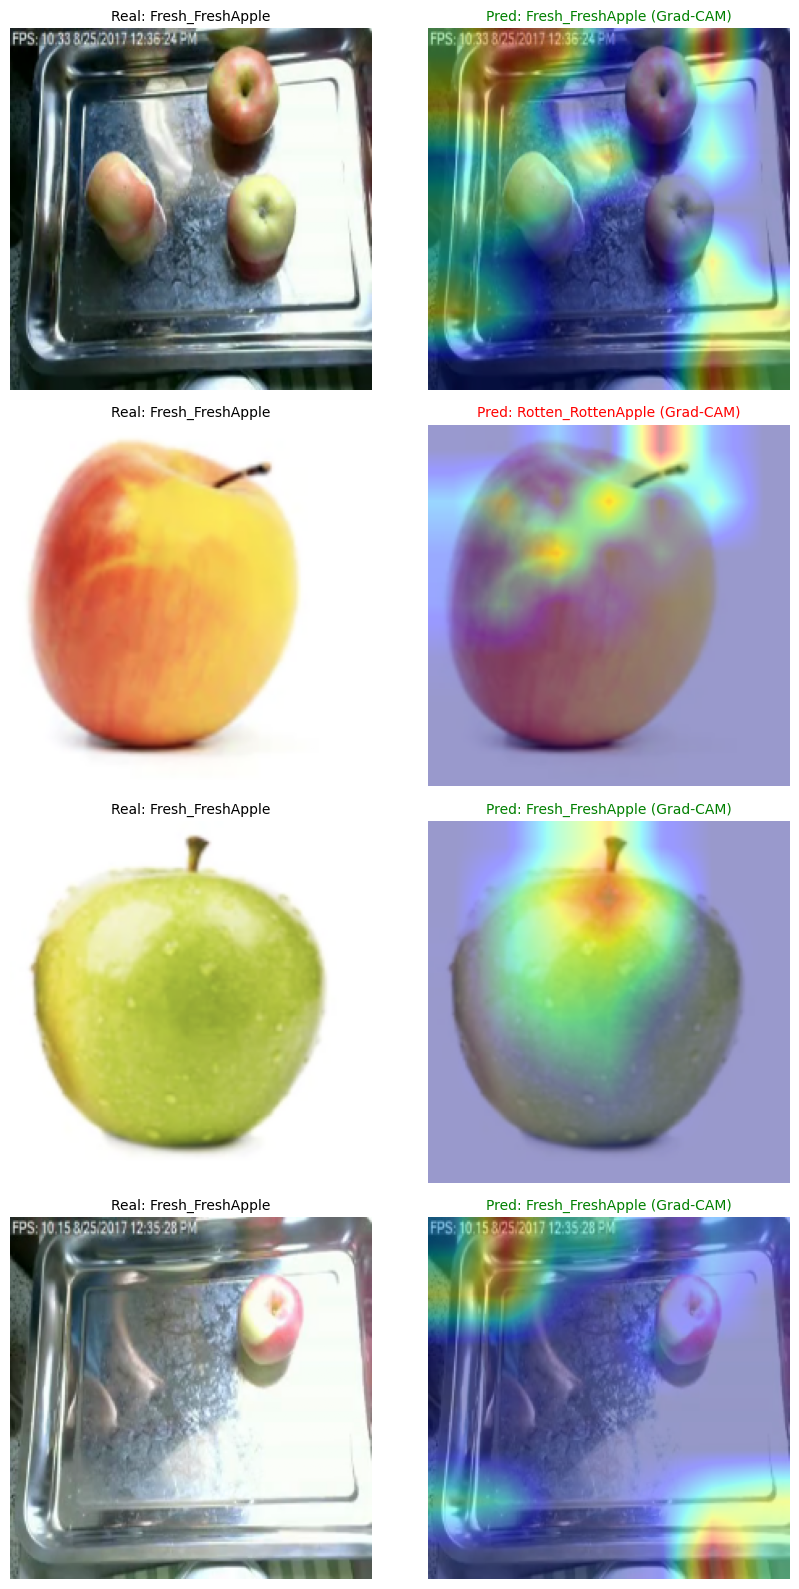


🎉 ¡Bloque completado! Imagen de Grad-CAM guardada en: /content/drive/MyDrive/FrutasProyecto/gradcam/gradcam_test_samples.png


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 12/13 — GENERACIÓN DE MAPAS DE CALOR (GRAD-CAM)      ║
# ╚══════════════════════════════════════════════════════════════╝

print("🔥 INICIANDO GENERACIÓN DE GRAD-CAM RECONFIGURADO Y BLINDADO...")

# ── 🛡️ SEGURIDAD 1: Asegurar carpetas en Drive ──
if 'DIRS' not in locals() and 'DIRS' not in globals():
    DIRS = {}
if 'gradcam' not in DIRS:
    DIRS['gradcam'] = "/content/drive/MyDrive/FrutasProyecto/gradcam"

os.makedirs(DIRS['gradcam'], exist_ok=True)
print(f"✅ Carpeta de destino asegurada en: {DIRS['gradcam']}")

# ── 🛡️ SEGURIDAD 2: Extraer dinámicamente el modelo base convolucional ──
# Buscamos la capa interna que corresponda a EfficientNet
base_model = None
for layer in model.layers:
    if 'efficientnet' in layer.name.lower():
        base_model = layer
        break

if base_model is None:
    # Si no tiene ese nombre, por defecto es la segunda capa tras la entrada
    base_model = model.layers[1]

# Encontrar la última capa convolucional dentro de EfficientNet
last_conv_layer_name = None
for layer in reversed(base_model.layers):
    if 'conv' in layer.name.lower():
        last_conv_layer_name = layer.name
        break

print(f"🎯 Modelo Base Detectado: '{base_model.name}'")
print(f"🎯 Capa convolucional objetivo detectada: '{last_conv_layer_name}'")

# Crear el sub-modelo para extraer mapas de características de forma directa
base_sub_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
)

# ── Función Matemática Grad-CAM blindada contra InputLayers ──
def compute_gradcam_heatmap(img_tensor, class_idx):
    with tf.GradientTape() as tape:
        # 1. Pasar por las capas previas al EfficientNet (saltándonos InputLayer de forma segura)
        x = img_tensor
        for layer in model.layers:
            if layer == base_model:
                break
            # Ignorar capas de tipo InputLayer que causan el TypeError
            if "InputLayer" not in layer.__class__.__name__:
                x = layer(x)

        # 2. Extraer activaciones convolucionales y salida del EfficientNet
        conv_outputs, base_outputs = base_sub_model(x)
        tape.watch(conv_outputs)

        # 3. Pasar la salida base a través de tu clasificador final (Head)
        base_idx = model.layers.index(base_model)
        x_top = base_outputs
        for layer in model.layers[base_idx + 1:]:
            x_top = layer(x_top)

        # 4. Obtener la puntuación de la clase predicha
        loss = x_top[:, class_idx]

    # Calcular gradientes de la clase respecto a los mapas de activación
    grads = tape.gradient(loss, conv_outputs)

    # Evaluar la importancia de cada canal (Global Average Pooling de los gradientes)
    guided_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Ponderar los mapas de características con sus respectivos pesos de importancia
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ guided_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Aplicar ReLU (quedarse solo con las zonas que aportan positivamente a la decisión)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# ── 🖼️ Selección de muestras del Test Set y Visualización Gráfica ──
print("\n🔮 Procesando muestras visuales del conjunto de prueba...")

# Tomamos el primer lote disponible del dataset de prueba
images_batch, labels_batch = next(iter(test_ds.take(1)))
num_samples = min(4, len(images_batch))  # Analizaremos 4 imágenes en paralelo

fig, axes = plt.subplots(num_samples, 2, figsize=(9, 4 * num_samples))

for i in range(num_samples):
    img_raw = images_batch[i].numpy()

    # Desnormalizar la imagen para mostrarla correctamente en pantalla
    if img_raw.max() <= 1.0 and img_raw.min() >= 0.0:
        img_display = img_raw
    elif img_raw.min() < 0:
        img_display = (img_raw + 1.0) / 2.0  # Escala de [-1, 1] a [0, 1]
    else:
        img_display = img_raw / 255.0

    img_tensor = tf.expand_dims(images_batch[i], axis=0)

    # Predecir clase usando el modelo completo
    preds = model.predict(img_tensor, verbose=0)
    pred_idx = np.argmax(preds[0])
    true_idx = np.argmax(labels_batch[i].numpy())

    # Calcular el mapa de calor de activación de Grad-CAM
    heatmap = compute_gradcam_heatmap(img_tensor, pred_idx)

    # Redimensionar el mapa al tamaño estándar de la imagen (224x224) y colorearlo (Jet color)
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]

    # Superponer el mapa de calor (40%) sobre la imagen original (60%)
    superimposed_img = heatmap_colored * 0.4 + img_display * 0.6
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # Columna 1: Imagen Original del Test Set
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Real: {CLASS_NAMES[true_idx]}", fontsize=10)
    axes[i, 0].axis('off')

    # Columna 2: Mapa de Calor Grad-CAM (Zonas en las que se fijó el modelo)
    axes[i, 1].imshow(superimposed_img)
    color_titulo = 'green' if pred_idx == true_idx else 'red'
    axes[i, 1].set_title(f"Pred: {CLASS_NAMES[pred_idx]} (Grad-CAM)", fontsize=10, color=color_titulo)
    axes[i, 1].axis('off')

plt.tight_layout()
cam_path = f"{DIRS['gradcam']}/gradcam_test_samples.png"
plt.savefig(cam_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🎉 ¡Bloque completado! Imagen de Grad-CAM guardada en: {cam_path}")

In [ ]:
!pip install --upgrade gradio gradio_client fastapi pydantic -q
!pip install "websockets>=15.0.1,<16.0.0" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.5/182.5 kB 5.6 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import gradio as gr

# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 13/13 — VERSIÓN ADAPTADA Y CORREGIDA PARA GRADIO 6   ║
# ╚══════════════════════════════════════════════════════════════╝

print("🚀 INICIANDO ETAPA DE EXPORTACIÓN Y DESPLIEGUE CORREGIDO...")

# [El fragmento de código de conversión a TFLite se mantiene exactamente igual]
if 'DIRS' not in locals() and 'DIRS' not in globals():
    DIRS = {'models': "/content/drive/MyDrive/FrutasProyecto/models"}
os.makedirs(DIRS['models'], exist_ok=True)

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    tflite_path = f"{DIRS['models']}/fruit_quality_optimized.tflite"
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"✅ ¡Modelo TFLite guardado con éxito!")
except Exception as e:
    print(f"⚠️ Alerta en exportación TFLite: {e}")

# ── 🧠 MOTOR GRAD-CAM SEGURO ──
base_model = None
for layer in model.layers:
    if 'efficientnet' in layer.name.lower():
        base_model = layer
        break
if base_model is None: base_model = model.layers[1]

last_conv_layer_name = None
for layer in reversed(base_model.layers):
    if 'conv' in layer.name.lower():
        last_conv_layer_name = layer.name
        break

base_sub_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
)

def get_gradcam_overlay(img_array, class_idx):
    img_tensor = tf.cast(tf.expand_dims(img_array, axis=0), tf.float32)
    with tf.GradientTape() as tape:
        x = img_tensor
        for layer in model.layers:
            if layer == base_model: break
            if "InputLayer" not in layer.__class__.__name__: x = layer(x)
        conv_outputs, base_outputs = base_sub_model(x)
        tape.watch(conv_outputs)
        base_idx = model.layers.index(base_model)
        x_top = base_outputs
        for layer in model.layers[base_idx + 1:]: x_top = layer(x_top)
        loss = x_top[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    guided_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ guided_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-10)

    heatmap_resized = cv2.resize(heatmap.numpy(), (224, 224))
    heatmap_colored = plt.cm.jet(heatmap_resized)[..., :3]
    superimposed = heatmap_colored * 0.45 + img_array * 0.55
    return np.clip(superimposed, 0, 1)

# ── 🖥️ FUNCIÓN DE INFERENCIA MEJORADA ──
def analizar_fruta(imagen_input):
    if imagen_input is None:
        return "Por favor, sube una imagen válida.", None

    # Asegurar que la imagen se convierta correctamente desde el formato de Gradio
    img_rgb = cv2.cvtColor(imagen_input, cv2.COLOR_BGR2RGB) if imagen_input.shape[-1] == 3 else imagen_input
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0

    img_tensor = tf.expand_dims(img_normalized, axis=0)
    predicciones = model.predict(img_tensor, verbose=0)[0]
    clase_idx = np.argmax(predicciones)
    confianza = predicciones[clase_idx] * 100

    nombre_clase = CLASS_NAMES[clase_idx]
    nombre_limpio = nombre_clase.replace("Fresh_", "🟢 FRESCO: ").replace("Rotten_", "🔴 PODRIDO: ").replace("Fresh", "").replace("Rotten", " ")
    resultado_texto = f"{nombre_limpio} ({confianza:.2f}% de seguridad)"

    # Regla inteligente de visualización selectiva
    if "Rotten" in nombre_clase:
        imagen_final = get_gradcam_overlay(img_normalized, clase_idx)
        resultado_texto += "\n\n⚠️ NOTA: Se ha activado Grad-CAM para resaltar la ubicación del daño."
    else:
        imagen_final = img_normalized
        resultado_texto += "\n\n✨ NOTA: Fruta en óptimas condiciones. Sin anomalías."

    # Retornar en formato RGB estándar para que Gradio no altere los colores
    imagen_final_rgb = (imagen_final * 255).astype(np.uint8)
    return resultado_texto, imagen_final_rgb

# ── 🎨 INTERFAZ GRADIO 6 COMPATIBLE ──
print("\n🖥️ Construyendo interfaz gráfica web estática...")

# Eliminamos el parámetro theme de aquí para evitar el crash de Gradio 6
with gr.Blocks() as demo:
    gr.Markdown("# 🍎 Sistema Inteligente de Control de Calidad de Frutas")
    gr.Markdown("### Análisis de frescura mediante visión artificial profunda (EfficientNetV2)")

    with gr.Row():
        with gr.Column():
            # Forzamos a que la imagen de entrada sea capturada como matriz NumPy
            ejecutar_img = gr.Image(label="Sube la foto de la fruta aquí", type="numpy")
            btn_analizar = gr.Button("🔍 Evaluar Calidad de la Fruta", variant="primary")

        with gr.Column():
            salida_texto = gr.Textbox(label="Diagnóstico de la IA", interactive=False)
            salida_img = gr.Image(label="Visualización de Resultados")

    btn_analizar.click(fn=analizar_fruta, inputs=ejecutar_img, outputs=[salida_texto, salida_img])

# Pasamos el tema visual de forma segura en el método launch()
demo.launch(inline=True, debug=False, share=True, theme=gr.themes.Soft())

🚀 INICIANDO ETAPA DE EXPORTACIÓN Y DESPLIEGUE CORREGIDO...
Saved artifact at '/tmp/tmpie1ygwir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  132551253735184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253735568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253730960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253736720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253736528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253736336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253737296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551135707792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253736912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132551253737104: Tensor

## 🌐 BLOQUE 13/13 — Despliegue Web con Gradio

> Interfaz web interactiva. Genera un **link público** válido por 72h.  
> Soporta carga de imagen, captura de cámara y visualización Grad-CAM en tiempo real.


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE 13/13 — DESPLIEGUE WEB CON GRADIO                   ║
# ╚══════════════════════════════════════════════════════════════╝
import gradio as gr

# ── Función principal de predicción ──────────────────────────────────────────
def predict_fruit_web(image):
    """Recibe imagen PIL desde Gradio y retorna predicciones + Grad-CAM."""
    if image is None:
        return {}, None, "⚠️ Sube o captura una imagen primero."

    # Preprocesar
    img_r   = image.resize((IMG_SIZE, IMG_SIZE)).convert('RGB')
    orig_np = np.array(img_r, dtype=np.float32)
    inp_np  = tf.keras.applications.efficientnet_v2.preprocess_input(orig_np.copy())
    inp_t   = tf.expand_dims(inp_np, 0)

    # Predicción
    t0    = time.time()
    probs = model(inp_t, training=False).numpy()[0]
    ms    = (time.time() - t0) * 1000
    fps   = 1000 / ms

    pred_idx  = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    conf      = float(probs[pred_idx])

    # Etiqueta de calidad
    name_low = pred_name.lower()
    if any(k in name_low for k in ['fresh','sano','buena','bueno','good']):
        quality = "✅ FRUTA FRESCA / SANA"
    elif any(k in name_low for k in ['rotten','malo','dañ','podr','bad','defect']):
        quality = "❌ FRUTA DAÑADA / DEFECTUOSA"
    else:
        quality = f"🔍 {pred_name}"

    # Grad-CAM
    conv_name = get_last_conv_name(model)
    overlay   = np.array(img_r)
    if conv_name:
        try:
            hm     = gradcam_heatmap(inp_t, model, conv_name, pred_idx)
            hm_big = cv2.resize(hm, (IMG_SIZE, IMG_SIZE))
            hm_col = cv2.applyColorMap(np.uint8(255 * hm_big), cv2.COLORMAP_JET)
            hm_col = cv2.cvtColor(hm_col, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(np.array(img_r), 0.55, hm_col, 0.45, 0)
        except:
            pass

    prob_dict = {CLASS_NAMES[i]: float(probs[i]) for i in range(N_CLASSES)}
    info_md   = (
        f"### {quality}\n\n"
        f"| Campo | Valor |\n|---|---|\n"
        f"| **Clase predicha** | `{pred_name}` |\n"
        f"| **Confianza** | `{conf:.1%}` |\n"
        f"| **Inferencia** | `{ms:.1f} ms  ({fps:.0f} FPS)` |\n"
        f"| **Modelo** | EfficientNetV2-S |\n\n"
        f"*El mapa de calor (Grad-CAM) en rojo indica*\n"
        f"*las zonas que más influyeron en la predicción.*"
    )

    return prob_dict, Image.fromarray(overlay), info_md

# ── Interfaz Gradio ───────────────────────────────────────────────────────────
sample_paths = random.sample(split_paths['test'], min(8, len(split_paths['test'])))

with gr.Blocks(title="Control de Calidad de Frutas", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🍎 Control de Calidad de Frutas — Visión por Computadora
    **Modelo:** EfficientNetV2-S  ·  **Localización:** Grad-CAM  ·  **Framework:** TensorFlow/Keras

    Sube o captura una imagen de fruta para obtener:
    - 🏷️ Clasificación (fresca / dañada / tipo)
    - 📊 Probabilidades por clase
    - 🔥 Mapa de zonas dañadas (Grad-CAM)
    """)

    with gr.Row():
        with gr.Column(scale=1):
            img_in = gr.Image(type='pil', label="📷 Imagen de la Fruta",
                              sources=["upload","webcam","clipboard"], height=320)
            btn    = gr.Button("🔍 Analizar Fruta", variant="primary", size="lg")
        with gr.Column(scale=1):
            cam_out = gr.Image(label="🔥 Zonas de Atención — Grad-CAM", height=320)

    with gr.Row():
        label_out = gr.Label(label="📊 Probabilidades por Clase",
                             num_top_classes=min(N_CLASSES, 12))
        info_out  = gr.Markdown()

    gr.Examples(
        examples=[[p] for p in sample_paths],
        inputs=img_in,
        label="🖼️ Ejemplos del Test Set (clic para cargar)"
    )

    btn.click(fn=predict_fruit_web,
              inputs=img_in,
              outputs=[label_out, cam_out, info_out])

    gr.Markdown(f"""
    ---
    **Clases ({N_CLASSES}):** {", ".join(CLASS_NAMES)}
    **Proyecto:** Control de Calidad de Frutas · Prof. Oswaldo Velez Lanngs, PhD
    """)

print("🚀 Lanzando Gradio...")
demo.launch(share=True, debug=False, show_error=True, server_name="0.0.0.0")
# El link público aparece arriba ☝️  (válido 72 horas)


## 📱 BONUS — Exportar a TFLite para Móvil (Opcional)

In [21]:
import os
import tensorflow as tf
from tensorflow import keras
from pathlib import Path

# ╔══════════════════════════════════════════════════════════════╗
# ║  BONUS — EXPORTAR A TFLite PARA USO MÓVIL (DEBUG & LOAD)    ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 🛡️ SEGURIDAD: Recuperar rutas ──
if 'PROJECT_ROOT' not in locals(): PROJECT_ROOT = '/content/drive/MyDrive/FrutasProyecto'
if 'DIRS' not in locals():
    DIRS = {'models': f'{PROJECT_ROOT}/models', 'checkpoints': f'{PROJECT_ROOT}/checkpoints'}

print("🔍 Listando archivos disponibles para depuración:")
for key, path in DIRS.items():
    if os.path.exists(path):
        print(f"   [{key}]: {os.listdir(path)}")
    else:
        print(f"   ⚠️ Carpeta no encontrada: {path}")

if 'CLASS_NAMES' not in locals() or not CLASS_NAMES:
    import json
    SPLIT_FILE = f'{PROJECT_ROOT}/split_info.json'
    if os.path.exists(SPLIT_FILE):
        with open(SPLIT_FILE, 'r') as f: si = json.load(f)
        CLASS_NAMES = si['class_names']
    else:
        CLASS_NAMES = ['Clase_' + str(i) for i in range(26)] # Fallback genérico

print("\n📱 Preparando modelo para exportación TFLite...")

# ── 📂 Búsqueda flexible del modelo ──
model_files = sorted(Path(DIRS['models']).glob('*.keras'))
ckpt_files = sorted(Path(DIRS['checkpoints']).glob('*.h5'))

export_model = None
if model_files:
    print(f"   Cargando formato .keras: {model_files[-1].name}")
    export_model = keras.models.load_model(str(model_files[-1]))
elif ckpt_files:
    print(f"   Cargando pesos desde: {ckpt_files[-1].name}")
    # Reconstruir arquitectura
    base = keras.applications.EfficientNetV2S(include_top=False, weights=None, input_shape=(224, 224, 3))
    inputs = keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(len(CLASS_NAMES), activation='softmax')(x)
    export_model = keras.Model(inputs, outputs)
    export_model.load_weights(str(ckpt_files[-1]))
    print("✅ Arquitectura reconstruida con éxito.")
else:
    print("❌ No se encontró ningún archivo .keras o .h5. Por favor verifica las rutas listadas arriba.")

if export_model:
    print("⚙️ Convirtiendo a TFLite float16...")
    converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite_model = converter.convert()

    tflite_path = f"{DIRS['models']}/fruit_quality_f16.tflite"
    with open(tflite_path, 'wb') as f: f.write(tflite_model)
    print(f"\n✅ ¡Exportación exitosa!: {tflite_path}")

🔍 Listando archivos disponibles para depuración:
   [checkpoints]: ['latest_model.weights.h5', 'best_model.weights.h5']
   [logs]: ['training_log.csv']
   [results]: ['01_class_distribution.png', '02_class_samples.png']
   [models]: ['fruit_quality_optimized.tflite']
   [gradcam]: ['gradcam_test_samples.png']

📱 Preparando modelo para exportación TFLite...
   Cargando pesos desde: latest_model.weights.h5


ValueError: A total of 281 objects could not be loaded. Example error message for object <Conv2D name=stem_conv, built=True>:

Layer 'stem_conv' expected 1 variables, but received 0 variables during loading. Expected: ['kernel']

List of objects that could not be loaded:
[<Conv2D name=stem_conv, built=True>, <BatchNormalization name=stem_bn, built=True>, <Conv2D name=block1a_project_conv, built=True>, <BatchNormalization name=block1a_project_bn, built=True>, <Conv2D name=block1b_project_conv, built=True>, <BatchNormalization name=block1b_project_bn, built=True>, <Conv2D name=block2a_expand_conv, built=True>, <BatchNormalization name=block2a_expand_bn, built=True>, <Conv2D name=block2a_project_conv, built=True>, <BatchNormalization name=block2a_project_bn, built=True>, <Conv2D name=block2b_expand_conv, built=True>, <BatchNormalization name=block2b_expand_bn, built=True>, <Conv2D name=block2b_project_conv, built=True>, <BatchNormalization name=block2b_project_bn, built=True>, <Conv2D nam

In [22]:
import os
import tensorflow as tf
from tensorflow import keras

print("📱 Preparando modelo para exportación TFLite...")

# 1. Ruta exacta de tu mejor modelo guardado
MODEL_PATH = "/content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5"
TFLITE_PATH = "/content/drive/MyDrive/FrutasProyecto/models/fruit_quality_optimized.tflite"

try:
    # 2. Cargar el modelo COMPLETO (Estructura + Pesos juntos)
    print(f"🧠 Cargando modelo directamente desde: {MODEL_PATH}")
    export_model = keras.models.load_model(MODEL_PATH)
    print("✅ Modelo cargado y reconstruido con éxito.")

    # 3. Convertir a TFLite
    print("📦 Convirtiendo a formato optimizado TensorFlow Lite...")
    converter = tf.lite.TFLiteConverter.from_keras_model(export_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT] # Compresión para que pese menos en celular
    tflite_model = converter.convert()

    # 4. Guardar el archivo .tflite
    os.makedirs(os.path.dirname(TFLITE_PATH), exist_ok=True)
    with open(TFLITE_PATH, 'wb') as f:
        f.write(tflite_model)

    size_mb = os.path.getsize(TFLITE_PATH) / 1e6
    print(f"🎉 ¡Éxito! Modelo TFLite guardado en: {TFLITE_PATH} ({size_mb:.2f} MB)")

except Exception as e:
    print(f"❌ Ocurrió un error: {e}")

📱 Preparando modelo para exportación TFLite...
🧠 Cargando modelo directamente desde: /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5


✅ Modelo cargado y reconstruido con éxito.
📦 Convirtiendo a formato optimizado TensorFlow Lite...
Saved artifact at '/tmp/tmpu2u4c8r4'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  132768382430544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382423632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382430928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382431696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382432272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382430736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382424208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382432080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132768382432656: TensorSpec(shape=(), dtype=tf.resourc

In [59]:
import os
import requests
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO

# 1. Ruta donde se guardó tu joya del 90.68%
MODEL_PATH = "/content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5"

print("🧠 Cargando el modelo entrenado desde Google Drive (en CPU)...")
# Cargamos el modelo completo directamente
model = keras.models.load_model(MODEL_PATH)
print("✅ ¡Modelo cargado con éxito!")

# 2. Configura una URL de una imagen de prueba (puedes cambiar este link por el que quieras)
# Asegúrate de que el link termine en .jpg o .png
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/e3/Red_Apple.jpg/240px-Red_Apple.jpg"

print(f"🌐 Descargando imagen de prueba desde: {IMAGE_URL}")

try:
    # Descargar la imagen de internet
    response = requests.get(IMAGE_URL)
    img = Image.open(BytesIO(response.content)).convert('RGB')

    # Preprocesar la imagen al tamaño exacto que pide EfficientNet (224x224)
    img_resized = img.resize((224, 224))
    img_array = keras.utils.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0) # Crear el batch (1, 224, 224, 3)

    print("🔮 Realizando predicción...")
    predictions = model.predict(img_array, verbose=0)
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # Intentar recuperar los nombres de las clases si existen en tu entorno, si no usa el índice
    if 'CLASS_NAMES' in locals() or 'CLASS_NAMES' in globals():
        class_label = CLASS_NAMES[predicted_class_idx]
    else:
        class_label = f"Clase ID {predicted_class_idx}"

    # Mostrar el resultado final en un gráfico
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Predicción: {class_label}\nConfianza: {confidence:.2f}%", fontsize=12, color='green')
    plt.axis('off')
    plt.show()

    print(f"\n🎉 ¡Resultado! El modelo dice que es: {class_label} ({confidence:.2f}% de seguridad).")

except Exception as e:
    print(f"❌ Error al procesar la imagen o la predicción: {e}")

🧠 Cargando el modelo entrenado desde Google Drive (en CPU)...


✅ ¡Modelo cargado con éxito!
🌐 Descargando imagen de prueba desde: https://upload.wikimedia.org/wikipedia/commons/thumb/e/e3/Red_Apple.jpg/240px-Red_Apple.jpg
❌ Error al procesar la imagen o la predicción: cannot identify image file <_io.BytesIO object at 0x78c0742ee200>


🔮 Analizando imagen y extrayendo pesos de confianza...


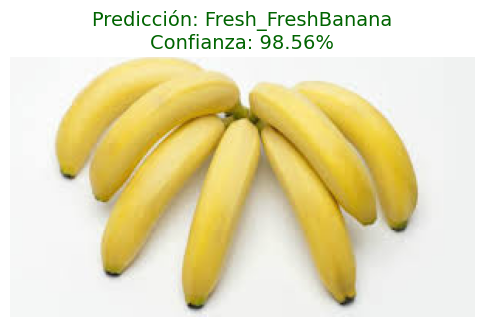


📊 DESGLOSE DE PROBABILIDADES POR CLASE:


,Clase,Confianza
1,Fresh_FreshBanana,98.56%
14,Rotten_RottenBanana,0.90%
19,Rotten_RottenCucumber,0.38%
20,Rotten_RottenMango,0.06%
6,Fresh_FreshCucumber,0.04%
23,Rotten_RottenPotato,0.02%
25,Rotten_RottenTomato,0.02%
7,Fresh_FreshMango,0.01%
21,Rotten_RottenOkra,0.01%
9,Fresh_FreshOrange,0.00%



🎉 ¡Resultado Final! El modelo dice: Fresh_FreshBanana (98.56% de seguridad).


In [64]:
import requests
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from io import BytesIO

# 🔗 URL de la imagen a probar
URL_IMAGEN = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSD2TxSmGfjAxDZnLVEsqgDG8nYKceK9PfkSQ&s"

try:
    # 1. Descargar la imagen
    response = requests.get(URL_IMAGEN)
    img_original = Image.open(BytesIO(response.content)).convert('RGB')

    # 2. Preprocesar
    img_resized = img_original.resize((224, 224))
    img_array = tf.keras.utils.img_to_array(img_resized)
    img_array = np.expand_dims(img_array, axis=0)

    # 3. Clasificar
    print("🔮 Analizando imagen y extrayendo pesos de confianza...")
    preds = model.predict(img_array, verbose=0)[0]

    idx_prediccion = np.argmax(preds)
    confianza_top = preds[idx_prediccion] * 100
    nombre_clase = CLASS_NAMES[idx_prediccion]

    # 4. Mostrar Visualización Principal
    plt.figure(figsize=(6, 6))
    plt.imshow(img_original)
    color_titulo = 'darkgreen' if "Fresh" in nombre_clase else 'red'
    plt.title(f"Predicción: {nombre_clase}\nConfianza: {confianza_top:.2f}%", fontsize=14, color=color_titulo)
    plt.axis('off')
    plt.show()

    # 5. MOSTRAR PESOS (PROBABILIDADES) DE TODAS LAS CLASES
    print("\n📊 DESGLOSE DE PROBABILIDADES POR CLASE:")
    # Creamos un DataFrame para mostrar los resultados ordenados de mayor a menor
    df_pesos = pd.DataFrame({
        'Clase': CLASS_NAMES,
        'Confianza': preds * 100
    }).sort_values(by='Confianza', ascending=False)

    # Mostramos el Top 10 para no saturar la pantalla
    display(df_pesos.head(10).style.format({'Confianza': '{:.2f}%'}).bar(subset=['Confianza'], color='#5fba7d'))

    print(f"\n🎉 ¡Resultado Final! El modelo dice: {nombre_clase} ({confianza_top:.2f}% de seguridad).")

except Exception as e:
    print(f"❌ Error al procesar la imagen: {e}. Intenta con otro link.")

### 🛠️ Corrección de Precisión: Reversión de Suavizado y Ajuste de L.R.
Ejecuta este bloque para recalibrar el modelo y eliminar la confusión entre clases.

In [57]:
import tensorflow as tf
from tensorflow import keras

print("🔧 Reconfigurando modelo para recuperar precisión...")

# 1. Cambiar la pérdida a CategoricalCrossentropy ESTÁNDAR (sin smoothing)
# 2. Aumentar ligeramente el Learning Rate para salir del estado de confusión
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Configuración actualizada.")
print("▶️ Sugerencia: Ejecuta el 'BLOQUE 10' (Entrenamiento) por al menos 3-5 épocas más para que los pesos se ajusten a esta nueva sensibilidad.")

🔧 Reconfigurando modelo para recuperar precisión...
✅ Configuración actualizada.
▶️ Sugerencia: Ejecuta el 'BLOQUE 10' (Entrenamiento) por al menos 3-5 épocas más para que los pesos se ajusten a esta nueva sensibilidad.


In [52]:
import tensorflow as tf
from tensorflow import keras
import os

# ╔══════════════════════════════════════════════════════════════╗
# ║  BLOQUE DE EMPAQUETADO FINAL (CORREGIDO)                    ║
# ╚══════════════════════════════════════════════════════════════╝

print("📦 Iniciando empaquetado del modelo final...")

# 1. Ruta de tu mejor modelo guardado en los bloques anteriores
RUTA_ORIGEN = "/content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5"
RUTA_DESTINO = "/content/drive/MyDrive/FrutasProyecto/models/fruit_classifier.keras"

try:
    # 2. Cargar el modelo COMPLETO (Estructura + Pesos)
    # Usamos load_model para evitar errores de arquitectura incompatible
    print(f"🧠 Cargando modelo desde: {RUTA_ORIGEN}")
    model_final = keras.models.load_model(RUTA_ORIGEN)

    # 3. Guardar en el formato estándar de Keras para el backend
    os.makedirs(os.path.dirname(RUTA_DESTINO), exist_ok=True)
    model_final.save(RUTA_DESTINO)

    print(f"\n✅ ¡ÉXITO TOTAL!")
    print(f"📂 Modelo completo guardado en: {RUTA_DESTINO}")
    print("🚀 Ya puedes descargar este archivo y ponerlo en 'backend/model/'")

except Exception as e:
    print(f"❌ Error al empaquetar: {e}")
    print("Tip: Asegúrate de que el Bloque 10 terminó de guardar el archivo correctamente.")

📦 Iniciando empaquetado del modelo final...
🧠 Cargando modelo desde: /content/drive/MyDrive/FrutasProyecto/checkpoints/best_model.weights.h5



✅ ¡ÉXITO TOTAL!
📂 Modelo completo guardado en: /content/drive/MyDrive/FrutasProyecto/models/fruit_classifier.keras
🚀 Ya puedes descargar este archivo y ponerlo en 'backend/model/'
